# Robust Online Inertia Estimation Method
Adapted from Liu et al. "On-Line Inertia Estimation for Synchronous and Non-Synchronous Devices", specifically their E2 method, which takes into account the controller's damping and primary frequency control. This helps to remove oscillations in their estimated inertia. 

In [1]:
%matplotlib inline

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [2]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"

case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")
STEP_TIME = 0.01 # 10 ms

## Load in case file and, run power flow and TDS

In [3]:
ss = andes.load(case_path, setup=False)
ss.REGF2.set("Tr",1,0.005)
#ss.REGF2.set("KPi",1,1)
#ss.REGF2.set("KPv",1,6)


print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 15 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.005]


True

In [4]:
# get frequency, RoCoF, and power time-series. 
tds_df = pd.concat([ss.TDS.get_timeseries(ss.BusROCOF.f), 
                    ss.TDS.get_timeseries(ss.BusROCOF.Wf_y), 
                    ss.TDS.get_timeseries(ss.REGF2.Pe)],
                    axis=1)

tds_df.columns = ["f", "df/dt", "p"]

tds_df

,f,df/dt,p
0.000000,1.000000,0.000000e+00,0.200000
0.000100,1.000000,0.000000e+00,0.200000
0.010100,1.000000,0.000000e+00,0.200000
0.020100,1.000000,0.000000e+00,0.200000
0.030100,1.000000,1.301203e-10,0.200000
...,...,...,...
14.976867,0.949979,-7.775506e-04,0.997974
14.986867,0.949975,-7.438744e-04,0.998282
14.996867,0.949971,-7.100407e-04,0.998646
14.999900,0.949970,-6.998992e-04,0.998765


## Inertia Calculation

In [5]:
t0 = 0
tf = 15

# these are taken from Liu et al.
#TM = 0.001
TM = 0.104
TD = 10e-4

eps_x = 10e-5
eps_w = 10e-5

In [6]:
# calculate RoCoF, derivative of RoCoF (RoRoCOF?? lol), and derivative of power (RoCoP)
# need to interpolate between values b/c continuous-- called by solver

domega_dt = CubicSpline(tds_df.index, tds_df.loc[:,"df/dt"])      
d2omega_dt2 = domega_dt.derivative()               
dp_dt = CubicSpline(tds_df.index, tds_df.loc[:,"p"]).derivative()

In [7]:
def gamma(x, eps):
    return np.where(x >= eps, -1.0, np.where(x <= -eps, 1.0, 0.0))

In [8]:
def rhs(t, y, TM, TD, eps_x, eps_w):
    Mstar, Dstar, domega_int, dp_int = y

    dp = dp_dt(t)
    d2w = d2omega_dt2(t)
    dw = domega_dt(t)

    dMstar = gamma(d2w, eps_x) * (dp - Mstar*d2w - Dstar*dw) / TM
    dDstar = gamma(domega_int, eps_w) * (dp_int - Mstar*dw - Dstar*domega_int) / TD
    ddomega_int = dw     
    ddp_int = dp  

    #plt.scatter(t, dp - Mstar*d2w - Dstar*dw, color="blue", s=1) # 's' controls the size
 
    return [dMstar, dDstar, ddomega_int, ddp_int]

In [9]:
sol = solve_ivp(rhs, [t0, tf], y0=[0, 0, 0, 0],
                 args=(TM, TD, eps_x, eps_w),
                 method='Radau', dense_output=True,
                 t_eval=tds_df.index)

#plt.show()


(0.0, 8.0)

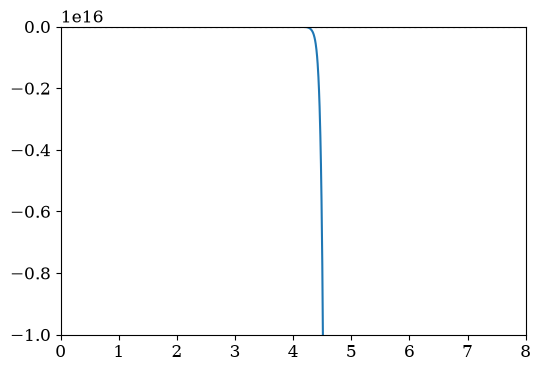

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sol.t, sol.y[0])
ax.axline((0, 5), slope=0, color="black", linestyle=":")
ax.set_ylim(-10000000000000000, 100000000)
ax.set_xlim(0, 8)

In [11]:
vals_df = pd.DataFrame(sol.y[:2]).T
vals_df.index = sol.t
vals_df.columns = ["M", "D"]
#vals_df

m_s = vals_df.loc[:,"M"]
m_s

0.000000      0.000000e+00
0.000100      0.000000e+00
0.010100      0.000000e+00
0.020100      0.000000e+00
0.030100      0.000000e+00
                 ...      
14.976867   -1.472637e+202
14.986867   -2.455428e+202
14.996867   -4.002386e+202
14.999900   -4.627785e+202
15.000000   -4.649899e+202
Name: M, Length: 2703, dtype: float64

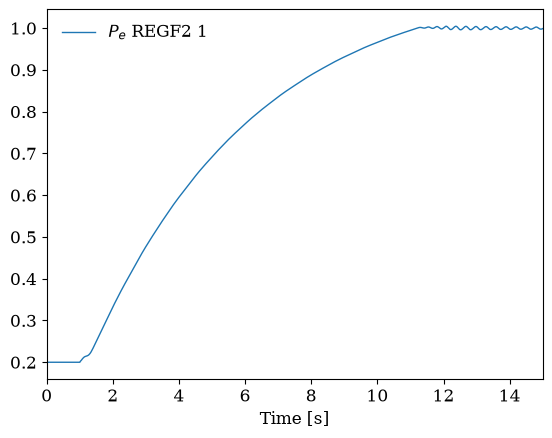

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [12]:
ss.TDS.plot(ss.REGF2.Pe)

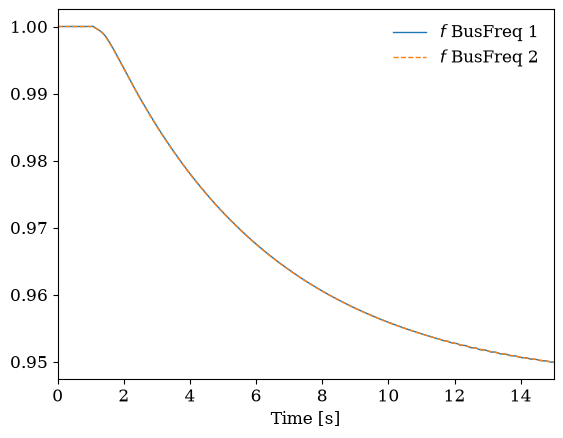

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [16]:
ss.TDS.plot(ss.BusFreq.f)

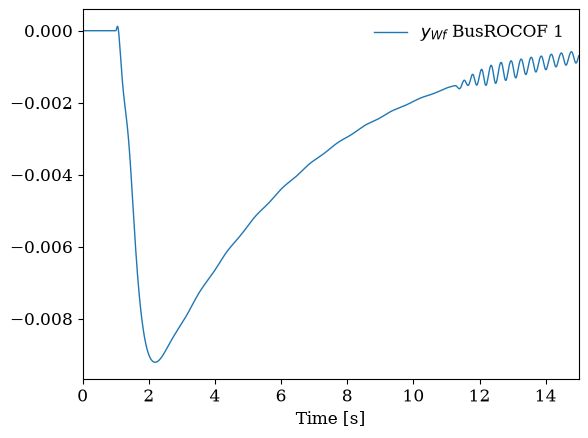

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [17]:
ss.TDS.plot(ss.BusROCOF.Wf_y)

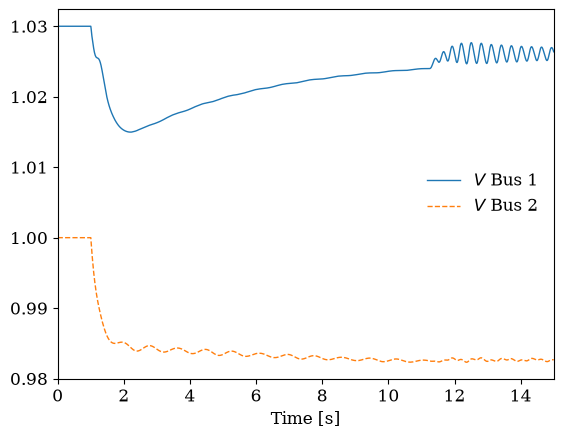

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [18]:
ss.TDS.plot(ss.Bus.v)

## Test External File

In [13]:
from calculate_metrics import calculate_metrics

In [14]:
metrics_df, M_ser = calculate_metrics(ss, True)

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/andes_env/lib/python3.11/site-packages/statsmodels/tools/eval_measures.py:40: RuntimeWarning: overflow encountered in square
  return np.mean((x1 - x2) ** 2, axis=axis)


In [15]:
M_ser

,0.005
0.000000,0.000000e+00
0.000100,0.000000e+00
0.010100,0.000000e+00
0.020100,0.000000e+00
0.030100,0.000000e+00
...,...
14.976867,-1.472637e+202
14.986867,-2.455428e+202
14.996867,-4.002386e+202
14.999900,-4.627785e+202
